## Classifier Model: KNearest Neighbors

In [10]:
from pathlib import Path
import sys

sys.path.append(str(Path.cwd().parents[1]))
from src.utils import plot_roc_curve, conf_matrix

In [11]:
from sklearn.metrics import accuracy_score, classification_report
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
import pandas as pd
import numpy as np

# import dataset 
df = pd.read_csv('../../data/processed/creditcard-processed.csv')
df.head()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


## Model Creation

Test Score: 0.999
Accuracy Score: 0.999


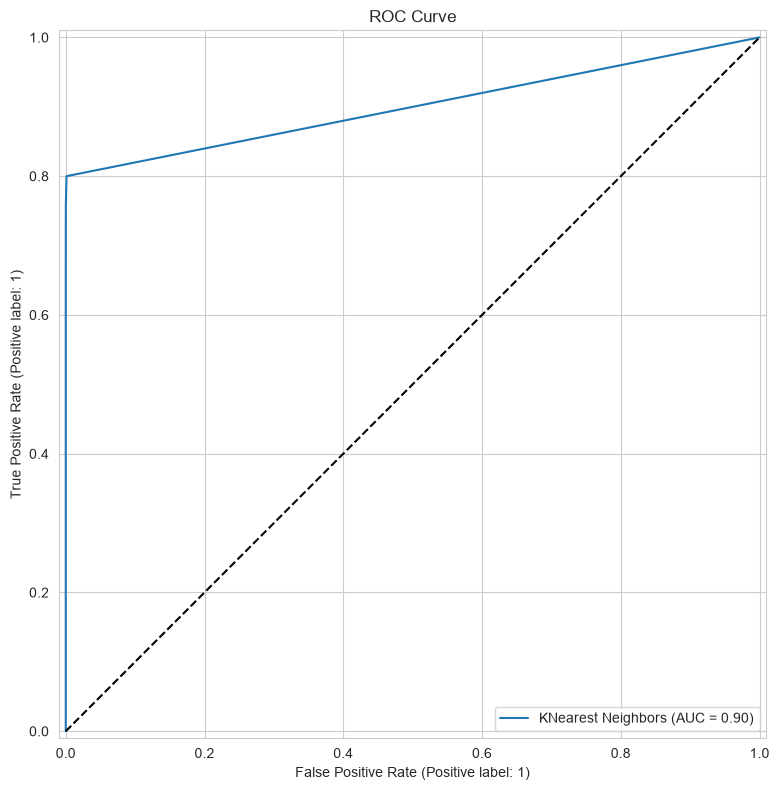

In [12]:
# split x and y feats
X = df.drop('Class', axis=1)
y = df['Class']

# init scaler
scaler = StandardScaler()

# split the train and test data into 80/20 split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train_scaled, y_train)
yhat_knn = knn.predict(X_test_scaled)

test_score = knn.score(X_test_scaled, y_test)
accuracy = accuracy_score(y_test, yhat_knn)

# threshold for a specific baseline
yhat_proba = knn.predict_proba(X_test_scaled)[:,1]
threshold = (yhat_proba >= 0.8).astype(int)

print(f"Test Score: {test_score:.3f}")
print(f"Accuracy Score: {accuracy:.3f}")
plot_roc_curve(knn, X_test_scaled, y_test, 'KNearest Neighbors')

## Confusion Matrix

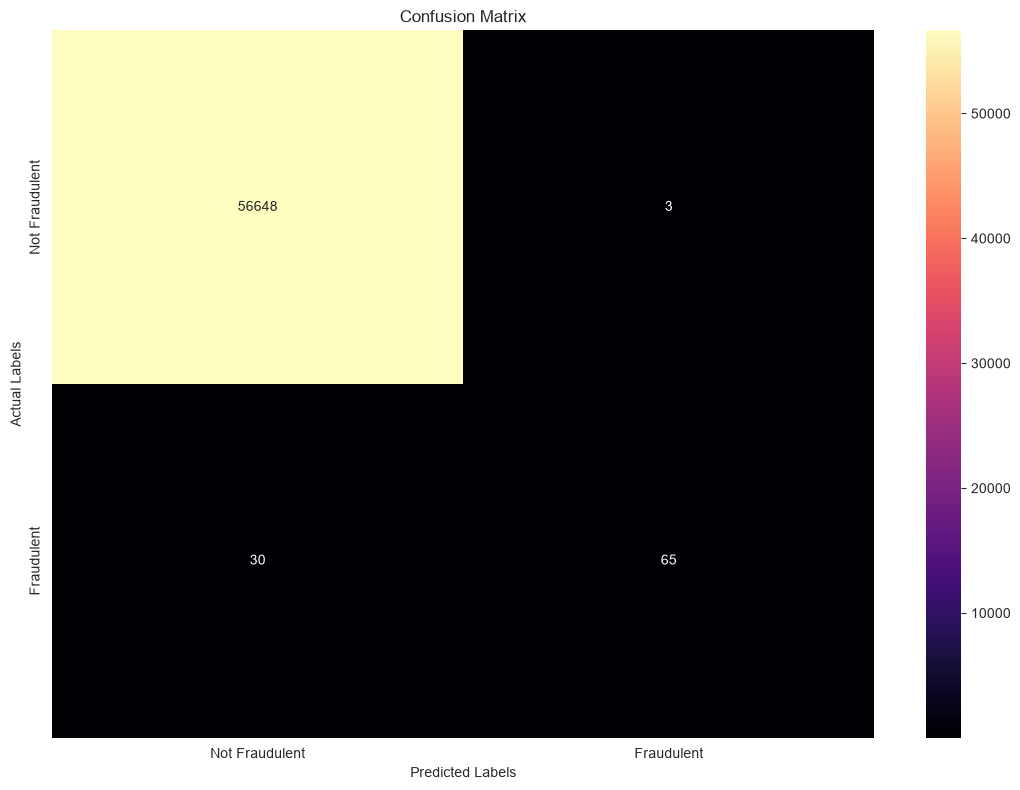

In [13]:
conf_matrix(y_test, yhat_knn, 
            ['Not Fraudulent', 'Fraudulent'])

### Confusion Matrix with an 80% Threshold

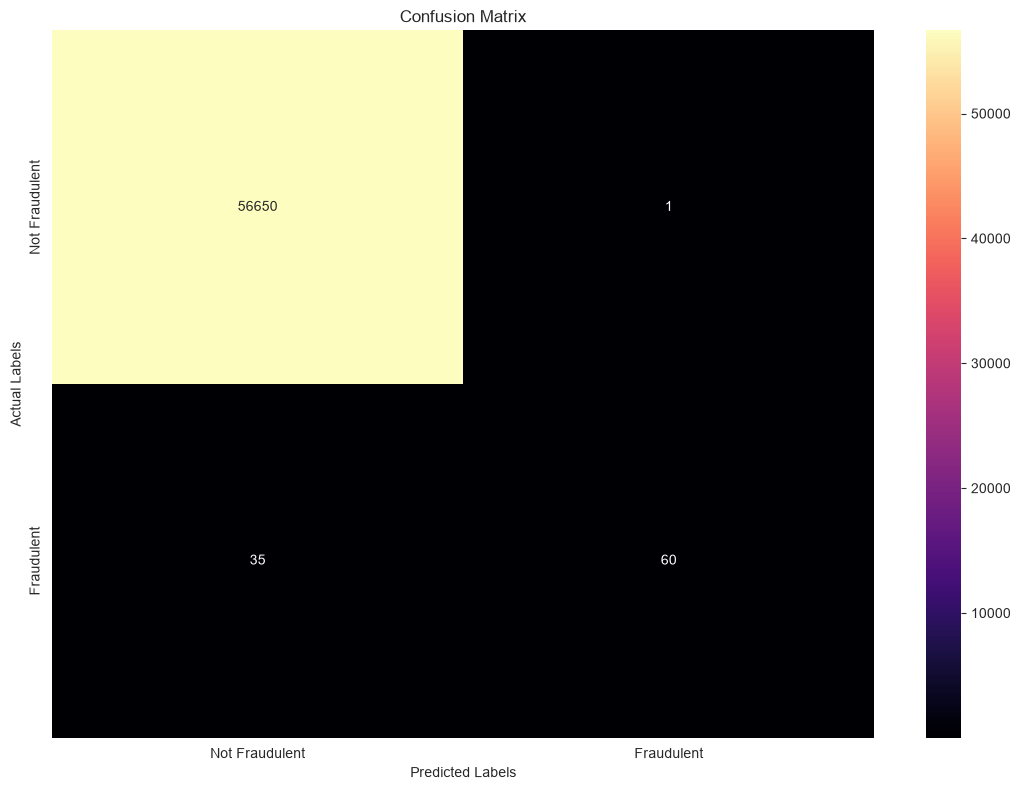

In [14]:
conf_matrix(y_test, threshold, ['Not Fraudulent', 'Fraudulent'])

## Classification Reports (with and without threshold)

In [15]:
print(classification_report(y_test, yhat_knn))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56651
           1       0.96      0.68      0.80        95

    accuracy                           1.00     56746
   macro avg       0.98      0.84      0.90     56746
weighted avg       1.00      1.00      1.00     56746



In [16]:
print(classification_report(y_test, threshold))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56651
           1       0.98      0.63      0.77        95

    accuracy                           1.00     56746
   macro avg       0.99      0.82      0.88     56746
weighted avg       1.00      1.00      1.00     56746



## Dataset Sampling
A noticeable class imbalanced within a non-fraudulent and fraudulent values within the `Class` column. Therefore, SMOT sampling will be utilize to compress the dataset into a more even class balance

#### Sampling Using SMOTE Sampling

In [17]:
from imblearn.over_sampling import SMOTE

rus = SMOTE(random_state=42)

X_train_sampled, y_train_resampled = rus.fit_resample(X_train, y_train)

X_train_scale = scaler.fit_transform(X_train_sampled)
X_test_scale = scaler.transform(X_test)

knn.fit(X_train_scale, y_train_resampled)
predict = knn.predict(X_test_scale)

test_sampled = knn.score(X_test_scale, y_test)
acc_score = accuracy_score(y_test, predict)

print(f"Test Score: {test_sampled:.3f}")
print(f"Accuracy Score: {acc_score:.3f}")
print(classification_report(y_test, predict))

Test Score: 0.998
Accuracy Score: 0.998
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56651
           1       0.45      0.77      0.57        95

    accuracy                           1.00     56746
   macro avg       0.73      0.88      0.78     56746
weighted avg       1.00      1.00      1.00     56746



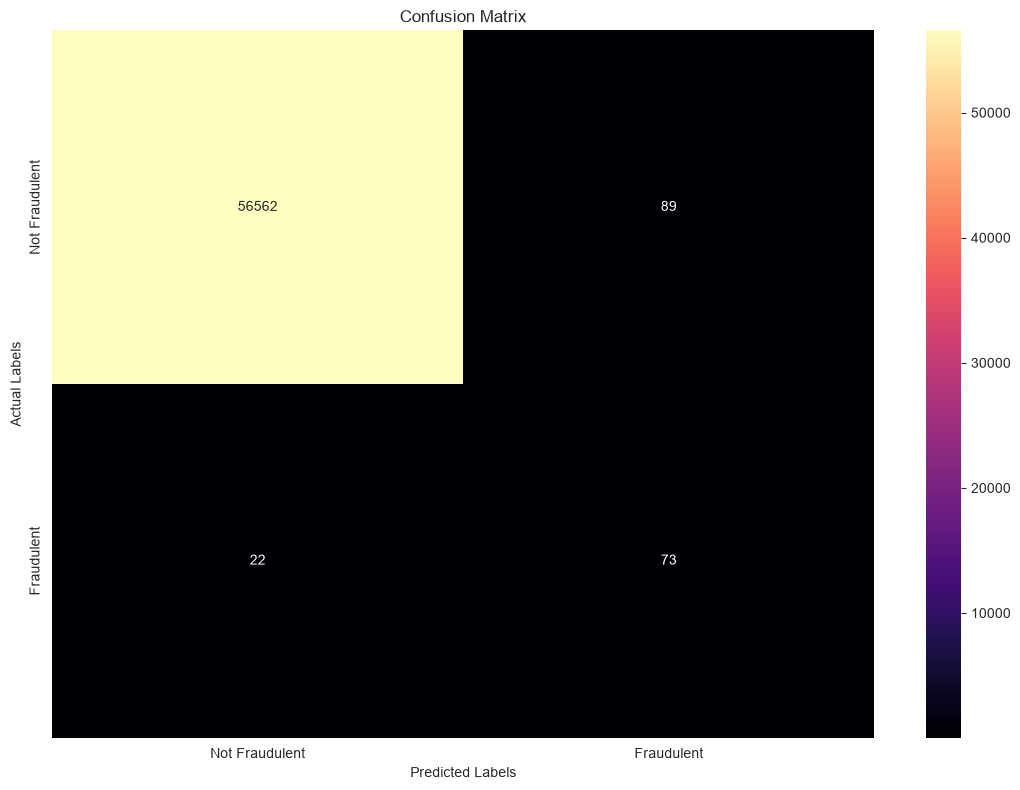

In [18]:
conf_matrix(y_test, predict, ['Not Fraudulent', 'Fraudulent'])